In [1]:
import numpy as np
from PIL import Image
import cv2
# from scipy.ndimage import gaussian_filter
import tensorflow as tf
# from sklearn.model_selection import train_test_split

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
TARGET_SIZE = (256, 256)

In [4]:
import pickle

In [5]:
BATCH_SIZE = 8
AUTOTUNE = tf.data.AUTOTUNE

train_ds=tf.data.Dataset.load('/content/drive/MyDrive/10000_data/train_dataset')
val_ds=tf.data.Dataset.load('/content/drive/MyDrive/10000_data/val_dataset')

In [7]:
# ── 4. Loss functions ───────────────────────────────────────────────────────
def dice_coefficient(y_true, y_pred, smooth=1.0):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )


def bce_dice_loss(y_true, y_pred):
    """Combined Binary Cross-Entropy + Dice Loss for stable training."""
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    bce = tf.reduce_mean(bce)
    dice = 1.0 - dice_coefficient(y_true, y_pred)
    return bce + dice

In [ ]:
# ── 5. Improved U-Net with BatchNorm + Dropout ──────────────────────────────
def build_unet(input_shape=(256, 256, 3)):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape, include_top=False, weights="imagenet"
    )

    skip_layer_names = [
        "block_1_expand_relu",   # 128x128
        "block_3_expand_relu",   # 64x64
        "block_6_expand_relu",   # 32x32
        "block_13_expand_relu",  # 16x16
    ]
    skips = [base_model.get_layer(name).output for name in skip_layer_names]
    x = base_model.output

    # Decoder with BatchNorm and Dropout
    for filters, skip in zip([512, 256, 128, 64], reversed(skips)):
        x = tf.keras.layers.UpSampling2D((2, 2))(x)
        x = tf.keras.layers.Concatenate()([x, skip])
        x = tf.keras.layers.Conv2D(filters, (3, 3), padding="same", use_bias=False)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
        x = tf.keras.layers.Conv2D(filters, (3, 3), padding="same", use_bias=False)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
        x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.UpSampling2D((2, 2))(x)
    x = tf.keras.layers.Conv2D(32, (3, 3), padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    outputs = tf.keras.layers.Conv2D(1, (1, 1), activation="sigmoid")(x)

    return tf.keras.Model(inputs=base_model.input, outputs=outputs)


In [ ]:
model = build_unet()

# ── Phase 1: Freeze encoder, train decoder only ─────────────────────────────
print("\n=== Phase 1: Training decoder (encoder frozen) ===")
for layer in model.layers:
    if layer.name.startswith("block_") or layer.name.startswith("Conv1") or layer.name.startswith("expanded_conv"):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=bce_dice_loss,
    metrics=[dice_coefficient],
)

phase1_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_dice_coefficient", patience=10, restore_best_weights=True, mode="max"
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_dice_coefficient", factor=0.5, patience=3, min_lr=1e-5, mode="max", verbose=1
    ),
]

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=phase1_callbacks,
)

/tmp/ipykernel_560/94602044.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

=== Phase 1: Training decoder (encoder frozen) ===
Epoch 1/30
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 388s 315ms/step - dice_coefficient: 0.6864 - loss: 0.4390 - val_dice_coefficient: 0.7444 - val_loss: 0.3694 - learning_rate: 0.0010
Epoch 2/30
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 202s 194ms/step - dice_coefficient: 0.7762 - loss: 0.3211 - val_dice_coefficient: 0.7593 - val_loss: 0.3458 - learning_rate: 0.0010
Epoch 3/30
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 202s 194ms/step - dice_coefficient: 0.8103 - loss: 0.2726 - val_dice_coefficient: 0.7743 - val_loss: 0.3287 - learning_rate: 0.0010
Epoch 4/30
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 202s 194ms/step - dice_coefficient: 0.8332 - loss: 0.2393 - val_dice_coefficient: 0.7830 - val_loss: 0.3125 - learning_rate: 0.0010
Epoch 5/30
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 202s 194ms/step - dice_coefficient: 0.8526 - loss: 0.2113 - val_dice_coefficient: 0.7866 - val_loss: 0.3157 - learning_rate: 0.0010
Epoch 6/30
1041/1041 ━━━━━━━━

In [ ]:
model.save_weights("unet_phase1_weights.weights.h5")

In [ ]:
len(train_ds)

441

In [ ]:
model = build_unet()
model.load_weights("/content/drive/MyDrive/unet_phase1_weights.weights.h5")
# ── Phase 2: Unfreeze encoder, fine-tune everything with low LR ─────────────
print("\n=== Phase 2: Fine-tuning entire model ===")
for layer in model.layers:
    layer.trainable = True

# Use cosine decay for smooth convergence
total_steps = len(train_ds) // BATCH_SIZE * 50
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    decay_steps=total_steps,
    alpha=1e-6,
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(lr_schedule),
    loss=bce_dice_loss,
    metrics=[dice_coefficient],
)

phase2_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_face_model.weights.h5",
        monitor="val_dice_coefficient",
        save_best_only=True,
        mode="max",
        save_weights_only=True,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_dice_coefficient", patience=20, restore_best_weights=True, mode="max"
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=phase2_callbacks,
)

# ── 7. Save ─────────────────────────────────────────────────────────────────
model.save("face_segmentation_model.keras")
print("Training complete. Model saved as face_segmentation_model.keras")

# Print final metrics
val_loss, val_dice = model.evaluate(val_ds, verbose=0)
print(f"Final validation Dice: {val_dice:.4f}")


/tmp/ipykernel_2692/94602044.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

=== Phase 2: Fine-tuning entire model ===
Epoch 1/50
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 430s 320ms/step - dice_coefficient: 0.8295 - loss: 0.2593 - val_dice_coefficient: 0.8063 - val_loss: 0.3025
Epoch 2/50
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 219s 210ms/step - dice_coefficient: 0.8793 - loss: 0.1722 - val_dice_coefficient: 0.8138 - val_loss: 0.2924
Epoch 3/50
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 218s 209ms/step - dice_coefficient: 0.9050 - loss: 0.1338 - val_dice_coefficient: 0.8125 - val_loss: 0.3071
Epoch 4/50
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 218s 209ms/step - dice_coefficient: 0.9227 - loss: 0.1082 - val_dice_coefficient: 0.8133 - val_loss: 0.3161
Epoch 5/50
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 225s 216ms/step - dice_coefficient: 0.9345 - loss: 0.0911 - val_dice_coefficient: 0.8130 - val_loss: 0.3231
Epoch 6/50
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 218s 209ms/step - dice_coefficient: 0.9420 - loss: 0.0803 - val_dice_coefficient: 0.8124 - val_loss: 0.3283
Epoch 7/

In [ ]:
import numpy as np
import time
import pandas as pd
import tensorflow as tf

def perform_final_evaluation(model, dataset):
    """
    Evaluates the model using a tf.data.Dataset object.
    Targets: Dice > 0.92, IoU > 0.88, F1 > 0.90, Inference < 100ms.
    """
    dice_scores = []
    iou_scores = []
    f1_scores = []
    inference_times = []

    print("Starting evaluation on dataset...")

    # Iterate through the tf.data.Dataset
    # Note: images and masks will arrive in batches based on your BATCH_SIZE (8)
    for images, masks in dataset:

        # 1. Measure Inference Speed
        # We time the entire batch and divide by batch size for an average per-sample time
        start_time = time.perf_counter()
        preds = model.predict(images, verbose=0)
        end_time = time.perf_counter()

        # Calculate average time per sample in this batch (in milliseconds)
        batch_size = tf.shape(images)[0].numpy()
        avg_inference_time = ((end_time - start_time) * 1000.0) / batch_size

        # We append the average for this batch for each sample in the batch
        for _ in range(batch_size):
            inference_times.append(avg_inference_time)

        # 2. Process Metrics for each item in the batch
        # Convert tensors to numpy for the metric logic
        preds_np = preds
        masks_np = masks.numpy()

        for i in range(batch_size):
            sample_mask_true = masks_np[i].flatten()
            # Binarize prediction
            y_pred = (preds_np[i].flatten() >= 0.5).astype(np.float32)

            # 3. Calculate Metrics
            intersection = np.sum(sample_mask_true * y_pred)
            sum_true = np.sum(sample_mask_true)
            sum_pred = np.sum(y_pred)
            union = sum_true + sum_pred - intersection

            # Dice Coefficient
            dice = (2.0 * intersection + 1e-7) / (sum_true + sum_pred + 1e-7)
            # IoU
            iou = (intersection + 1e-7) / (union + 1e-7)
            # F1-Score
            precision = (intersection + 1e-7) / (sum_pred + 1e-7)
            recall = (intersection + 1e-7) / (sum_true + 1e-7)
            f1 = (2 * precision * recall) / (precision + recall + 1e-7)

            dice_scores.append(dice)
            iou_scores.append(iou)
            f1_scores.append(f1)

    # Aggregate Results
    metrics_summary = {
        'Metric': ['Dice Coefficient', 'IoU', 'F1-Score', 'Avg Inference Time'],
        'Actual': [
            np.mean(dice_scores),
            np.mean(iou_scores),
            np.mean(f1_scores),
            np.mean(inference_times)
        ],
        'Target': ['> 0.92', '> 0.88', '> 0.90', '< 100ms']
    }

    df = pd.DataFrame(metrics_summary)
    df['Pass'] = [
        '✅' if df.loc[0, 'Actual'] > 0.92 else '❌',
        '✅' if df.loc[1, 'Actual'] > 0.88 else '❌',
        '✅' if df.loc[2, 'Actual'] > 0.90 else '❌',
        '✅' if df.loc[3, 'Actual'] < 100.0 else '❌'
    ]

    print("\n" + "="*50)
    print("FINAL EVALUATION MATRIX (TF.DATA)")
    print("="*50)
    # Custom formatting for the printout
    for i, row in df.iterrows():
        val = f"{row['Actual']:.4f}" if i < 3 else f"{row['Actual']:.2f}ms"
        print(f"{row['Metric']:20} | {val:10} | Target: {row['Target']:8} | {row['Pass']}")
    print("="*50)

    return df

# Usage
# Pass your existing val_ds object here
results_df = perform_final_evaluation(model, val_ds)

Starting evaluation on dataset...

FINAL EVALUATION MATRIX (TF.DATA)
Dice Coefficient     | 0.7613     | Target: > 0.92   | ❌
IoU                  | 0.6646     | Target: > 0.88   | ❌
F1-Score             | 0.7613     | Target: > 0.90   | ❌
Avg Inference Time   | 25.14ms    | Target: < 100ms  | ✅


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
def predict_local_image(image_path):
    # 2. Load and Preprocess the image
    raw_img = Image.open(image_path).convert("RGB")
    # Resize to the target size used in training (256x256) [cite: 9, 12]
    img_resized = raw_img.resize((256, 256), Image.BILINEAR)
    img_array = np.array(img_resized).astype(np.float32)

    # Normalize pixel values to [0, 1] [cite: 9, 13]
    img_tensor = img_array / 255.0
    # Add batch dimension: (1, 256, 256, 3) [cite: 68, 74]
    img_tensor = np.expand_dims(img_tensor, axis=0)

    # 3. Perform Inference
    prediction = model.predict(img_tensor, verbose=0)[0]

    # 4. Binarize the mask at 0.5 threshold [cite: 9, 75]
    mask = (prediction >= 0.5).astype(np.uint8)

    # 5. Visualization
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img_resized)
    ax[0].set_title("Downloaded Image")
    ax[0].axis('off')

    ax[1].imshow(mask[:, :, 0], cmap='gray')
    ax[1].set_title("Predicted Face Mask")
    ax[1].axis('off')
    plt.show()

# Example usage:
# predict_local_image('my_downloaded_face.jpg')

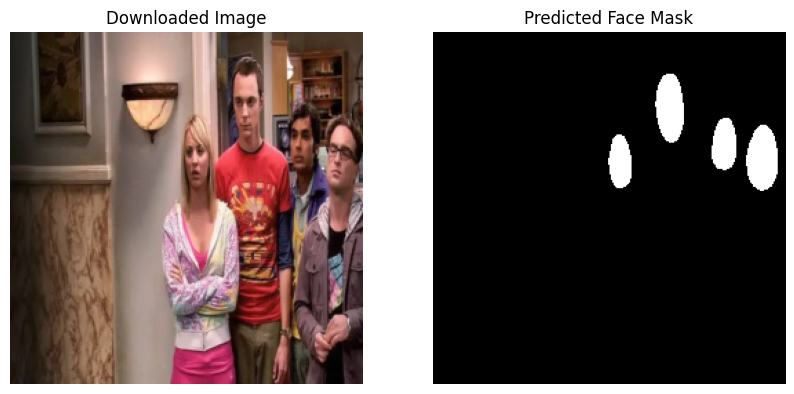

In [ ]:
predict_local_image('/content/drive/MyDrive/bingbang.webp')

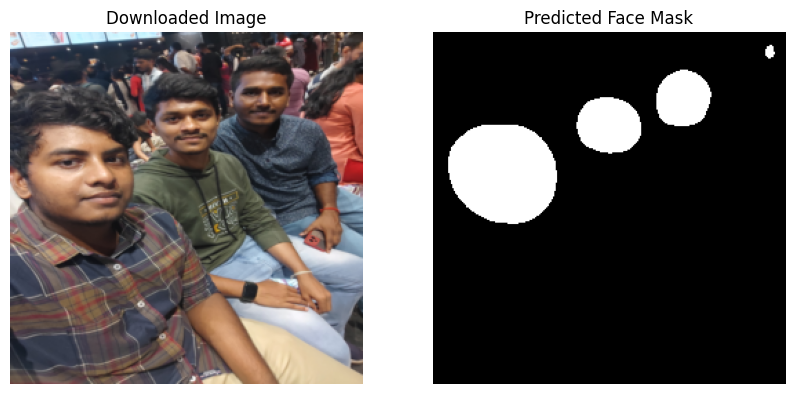

In [ ]:
predict_local_image('/content/drive/MyDrive/1682952359153.jpg')

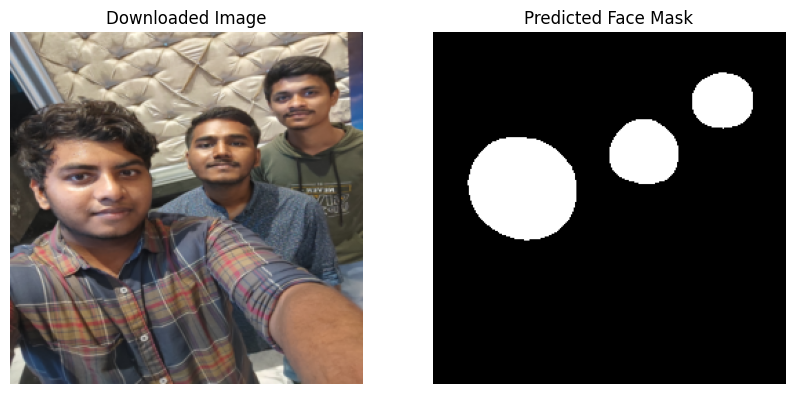

In [ ]:
predict_local_image('/content/drive/MyDrive/1682952359159.jpg')

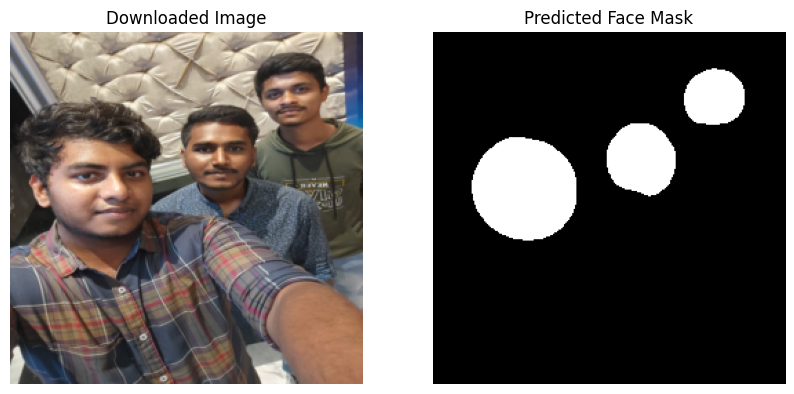

In [ ]:
predict_local_image('/content/drive/MyDrive/1682952359165.jpg')

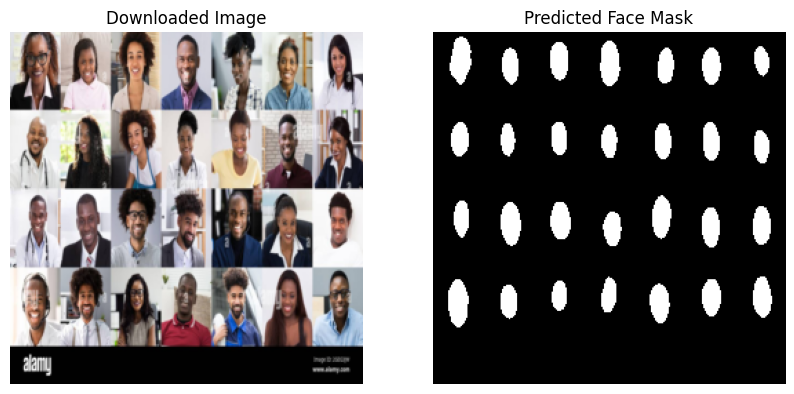

In [ ]:
predict_local_image('/content/drive/MyDrive/african-people-faces-collage-set-avatar-group-2GEG3JW.jpg')

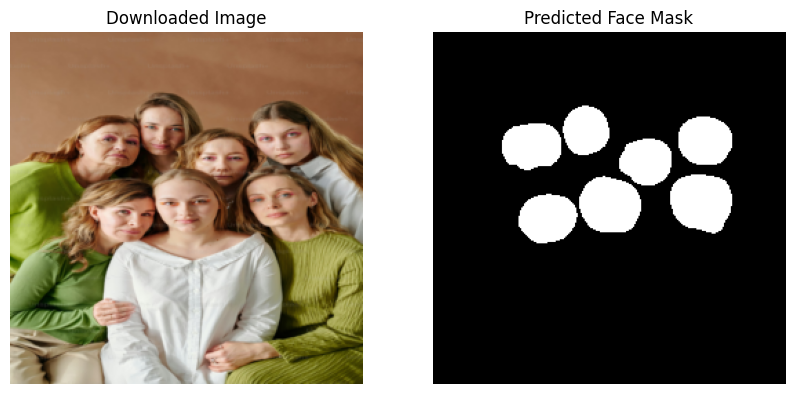

In [ ]:
predict_local_image('/content/drive/MyDrive/premium_photo-1679415150611-9b24a9d3ce48.avif')

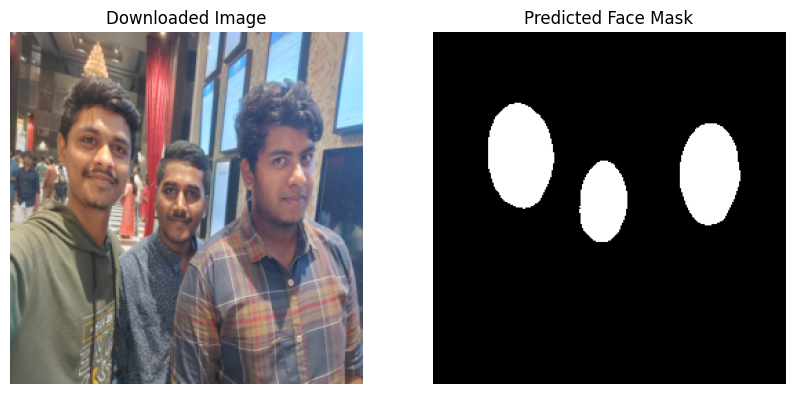

In [ ]:
predict_local_image('/content/drive/MyDrive/1682952359176.jpg')

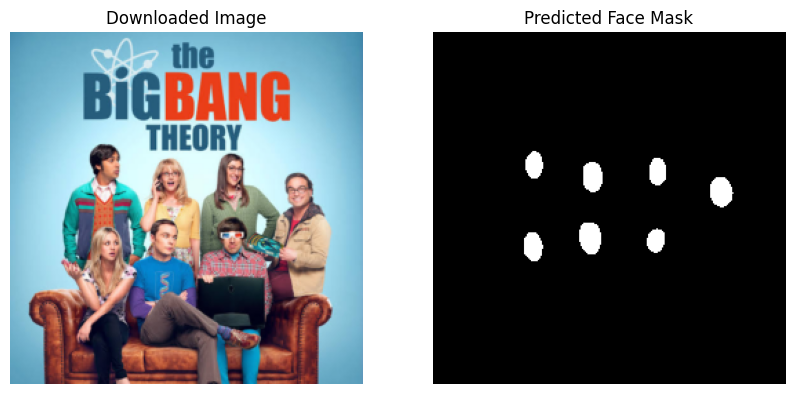

In [ ]:
predict_local_image('/content/drive/MyDrive/images (1).jpg')

In [11]:
model_adam = tf.keras.models.load_model('/content/drive/MyDrive/face_segmentation_model_10000.keras',
    custom_objects={'bce_dice_loss': bce_dice_loss,'dice_coefficient':dice_coefficient})

In [12]:
model_adamw = tf.keras.models.load_model('/content/drive/MyDrive/face_segmentation_model_adamw.keras',
    custom_objects={'bce_dice_loss': bce_dice_loss,'dice_coefficient':dice_coefficient})

In [13]:
model_sgd = tf.keras.models.load_model('/content/drive/MyDrive/face_segmentation_model_sgd.keras',
    custom_objects={'bce_dice_loss': bce_dice_loss,'dice_coefficient':dice_coefficient})

In [14]:
import numpy as np
import time
import pandas as pd
import tensorflow as tf

def compare_optimizers_evaluation(models_list, dataset):
    """
    Evaluates multiple models and structures the output by Optimizer.
    Input format: [{'model': model_obj, 'optimizer': 'Adam'}, ...]
    Returns a DataFrame with Optimizers as rows and metrics as columns.
    """
    all_results = []

    for model_info in models_list:
        model = model_info['model']
        optimizer_name = model_info['optimizer']

        print(f"Evaluating model with optimizer: {optimizer_name}...")

        dice_scores = []
        iou_scores = []
        f1_scores = []
        inference_times = []

        for images, masks in dataset:
            # 1. Measure Inference Speed
            start_time = time.perf_counter()
            preds = model.predict(images, verbose=0)
            end_time = time.perf_counter()

            batch_size = tf.shape(images)[0].numpy()
            avg_inference_time = ((end_time - start_time) * 1000.0) / batch_size

            for _ in range(batch_size):
                inference_times.append(avg_inference_time)

            # 2. Process Metrics
            preds_np = preds
            masks_np = masks.numpy()

            for i in range(batch_size):
                sample_mask_true = masks_np[i].flatten()
                y_pred = (preds_np[i].flatten() >= 0.5).astype(np.float32)

                intersection = np.sum(sample_mask_true * y_pred)
                sum_true = np.sum(sample_mask_true)
                sum_pred = np.sum(y_pred)
                union = sum_true + sum_pred - intersection

                dice = (2.0 * intersection + 1e-7) / (sum_true + sum_pred + 1e-7)
                iou = (intersection + 1e-7) / (union + 1e-7)

                precision = (intersection + 1e-7) / (sum_pred + 1e-7)
                recall = (intersection + 1e-7) / (sum_true + 1e-7)
                f1 = (2 * precision * recall) / (precision + recall + 1e-7)

                dice_scores.append(dice)
                iou_scores.append(iou)
                f1_scores.append(f1)

        # Append aggregated row data for this specific optimizer
        all_results.append({
            'Optimizer': optimizer_name,
            'Dice Coefficient': np.mean(dice_scores),
            'IoU': np.mean(iou_scores),
            'F1-Score': np.mean(f1_scores),
            'Avg Inference Time': np.mean(inference_times)
        })

    # Create the final comparison DataFrame
    comparison_df = pd.DataFrame(all_results)
    comparison_df.set_index('Optimizer', inplace=True)

    return comparison_df


In [15]:

models_to_test = [
    {'model': model_adam, 'optimizer': 'Adam'},
    {'model': model_sgd, 'optimizer': 'SGD'},
    {'model': model_adamw, 'optimizer': 'AdamW'}
]

comparison_df = compare_optimizers_evaluation(models_to_test, val_ds)

print(comparison_df)


Evaluating model with optimizer: Adam...
Evaluating model with optimizer: SGD...
Evaluating model with optimizer: AdamW...
           Dice Coefficient       IoU  F1-Score  Avg Inference Time
Optimizer                                                          
Adam               0.761299  0.664617  0.761299           43.391521
SGD                0.743900  0.643270  0.743900           27.075035
AdamW              0.757944  0.661962  0.757944           26.234447


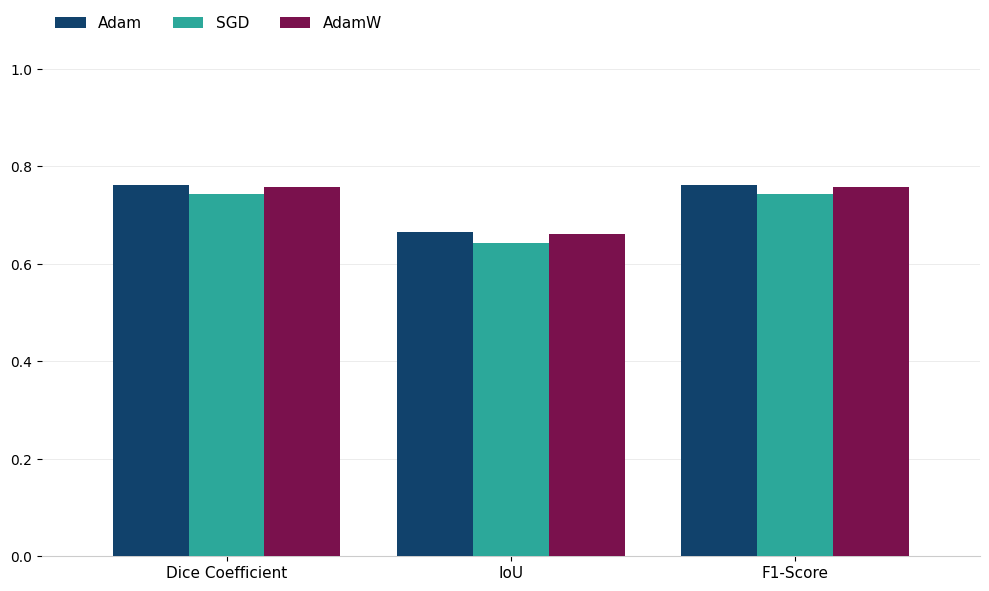

In [17]:
import matplotlib.pyplot as plt

# 1. Select only the accuracy metrics for the 0-1 scale chart
metrics = ['Dice Coefficient', 'IoU', 'F1-Score']

# 2. Transpose the dataframe to group by metric on the X-axis
plot_df = comparison_df[metrics].T

# 3. Create the clustered bar plot
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#11426c', '#2ca89a', '#7a114d']
plot_df.plot(kind='bar', ax=ax, color=colors, width=0.8, zorder=3)

# 4. Strictly format the axes and design to match your image
ax.set_ylim(0, 1.0)
ax.set_xticklabels(metrics, rotation=0, fontsize=11)


for spine in ['top', 'left', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')

ax.grid(axis='y', linestyle='-', linewidth=0.5, color='#e5e5e5', zorder=0)

# Position the legend horizontally at the top left corner
ax.legend(
    bbox_to_anchor=(0.0, 1.05),
    loc='lower left',
    ncol=len(comparison_df.index),
    frameon=False,
    fontsize=11
)
plt.tight_layout()
plt.show()
